# 2f Cut Study

In [1]:
import os, glob, sqlite3, datetime
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from Dpipe.load_ptod import DpipeTODCuts

DB    = '/data/users/class/dpipe_db/w1_templates_20260203.db'
DTOD  = '/data/users/class/mapmaking_in/dtod/w1_band/56lp'      #demod version
ADCSV = '/home/carolcyy/moby/Dpipe/data/ArrayData/w1_band/current/array_data.csv'
CACHE = '/tmp/2f_cut_study_meta.npz'
NDET  = 616

# calibrated per-segment 2f metric used by the cuts = |amplitude * scaling_factor|
# the 4 ModTemplate cut files:
F2F = ['ModTemplateLowMedian_0.01045', 'ModTemplateHighVariance_4e-05',
       'ModTemplateAmplitudeOutlier_1.5', 'ModTemplateQualityAmpConditionCut_Q0.95_A0.005']
SHORT = ['LowMedian', 'HighVariance', 'AmpOutlier', 'QualAmpCond']
CCOL  = ['C0', 'C1', 'C2', 'C3']
MINMED, MINBASE, QTHR = 0.01045, 0.0125, 0.95     # LowMedian thr / pre-filter amp / quality

In [2]:
# --- per-detector mean 2f amplitude (one DB pass, cached) ---
if os.path.exists(CACHE):
    z = np.load(CACHE); MEAN2f, MQUAL, NSEG = z['mean2f'], z['mqual'], z['nseg']
    tmin, tmax, nseg_tot, nspan_db = float(z['tmin']), float(z['tmax']), int(z['nseg_tot']), int(z['nspan'])
else:
    con = sqlite3.connect(f'file:{DB}?mode=ro', uri=True)
    MEAN2f = np.full(NDET, np.nan); MQUAL = np.full(NDET, np.nan); NSEG = np.zeros(NDET, int)
    for u, m, q, n in con.execute("""SELECT det_uid, AVG(ABS(amplitude*scaling_factor)),
                                     AVG(quality), COUNT(*) FROM templates GROUP BY det_uid"""):
        if u < NDET: MEAN2f[u], MQUAL[u], NSEG[u] = m, q, n
    tmin, tmax = con.execute("SELECT MIN(timestamp),MAX(timestamp) FROM segments").fetchone()
    nseg_tot = con.execute("SELECT COUNT(*) FROM segments").fetchone()[0]
    nspan_db = con.execute("SELECT COUNT(*) FROM spans").fetchone()[0]
    con.close()
    np.savez(CACHE, mean2f=MEAN2f, mqual=MQUAL, nseg=NSEG,
             tmin=tmin, tmax=tmax, nseg_tot=nseg_tot, nspan=nspan_db)

ad   = pd.read_csv(ADCSV).set_index('det_uid')
ROW  = ad['row'].reindex(range(NDET)).values
LIVE = NSEG > 0.5 * np.median(NSEG[NSEG > 0])       # detectors with substantial data

d0, d1 = (datetime.datetime.utcfromtimestamp(t).date() for t in (tmin, tmax))
print(f"detectors in DB : {np.isfinite(MEAN2f).sum()}   (of {NDET};  live={LIVE.sum()})")
print(f"spans (DB)      : {nspan_db}        spans (dtod cut files): "
      f"{len(glob.glob(f'{DTOD}/2024-*')+glob.glob(f'{DTOD}/2025-*'))}")
print(f"segments total  : {nseg_tot}")
print(f"date range      : {d0} -> {d1}")
print(f"mean 2f (live)  : median={np.nanmedian(MEAN2f[LIVE]):.4f}  "
      f"min={np.nanmin(MEAN2f[LIVE]):.4f}  max={np.nanmax(MEAN2f[LIVE]):.4f}")

detectors in DB : 345   (of 616;  live=332)
spans (DB)      : 290        spans (dtod cut files): 286
segments total  : 86606
date range      : 2024-07-01 -> 2025-08-29
mean 2f (live)  : median=0.0164  min=0.0005  max=0.0247


## Carol's testing

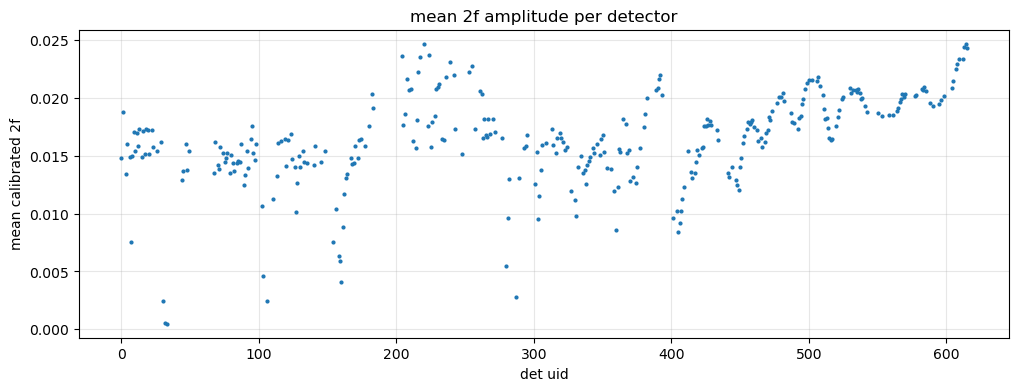

 uid  row   mean2f
  33   10   0.0005
  32   11   0.0005
  30   13   0.0024
 106   18   0.0025
 287   20   0.0028
 160   15   0.0041
 103   15   0.0046
 280   16   0.0055
 159   16   0.0059
 158   17   0.0063
 154   21   0.0075
   7    7   0.0076
 405    9   0.0084
 360    8   0.0086
 161   14   0.0088
 406   10   0.0092
 303    4   0.0095
 401    5   0.0096
 281   17   0.0096
 331   20   0.0098
 127    4   0.0101
 407   11   0.0102
 404    8   0.0102
 156   19   0.0104
 102   14   0.0106
 330   21   0.0112
 408   12   0.0112
 110   21   0.0113
 304    3   0.0115
 162   13   0.0117
 358    6   0.0119
 327   19   0.0120
 449    9   0.0120
 361    9   0.0123
 409   13   0.0123
 448    8   0.0124
  89    1   0.0125
 301    6   0.0125
 338   13   0.0126
 374   21   0.0126
 128    3   0.0126
 370   18   0.0128
  44    0   0.0129
 447    7   0.0129
 282   18   0.0130
 289   18   0.0130
 415   19   0.0131
 163   12   0.0131
 372   20   0.0132
 442    2   0.0132
 113   18   0.0132
  90    2   

In [3]:
uids = np.where(LIVE & np.isfinite(MEAN2f))[0]
plt.figure(figsize=(12, 4))
plt.plot(uids, MEAN2f[uids], '.', ms=4)
plt.xlabel('det uid'); plt.ylabel('mean calibrated 2f')
plt.grid(alpha=.3); plt.title('mean 2f amplitude per detector')
plt.show()

# uids from lowest to highest mean 2f gain
order = uids[np.argsort(MEAN2f[uids])]
print(f"{'uid':>4} {'row':>4} {'mean2f':>8}")
for u in order:
    print(f"{u:>4} {int(ROW[u]):>4} {MEAN2f[u]:>8.4f}")

- data cuts are defined in Dpipe/src/Dpipe/cuts.py
- the four 2f relevant cuts ar:
    1. ModTemplateLowMedianCut — class cuts.py:639, stat identify_low_median_detectors:2247
    Whole-detector cut. Computes the median of |amp×scale| over that detector's segments that survive the pre-filter, and cuts the detector for the entire span if median < min_median_amplitude = 0.01045.

    2. ModTemplateHighVarianceCut — class cuts.py:587, stat identify_high_variance_detectors:2336
    Whole-detector cut. Variance of |amp×scale| over the (pre-filtered) segments; cuts the detector if variance > max_variance = 4.382e-5. Targets unstable/jumpy detectors.
    
    3. ModTemplateAmplitudeOutlierCut — class cuts.py:691, stat identify_amplitude_outliers_iqr:2431
    Per-package (per-segment) cut. Builds database-wide per-detector IQR bounds [Q1−1.5·IQR, Q3+1.5·IQR] on the pre-filtered values, then cuts only the individual packages in this span whose value falls outside those bounds. Targets transient outlier packages.

    4. ModTemplateQualityAmpConditionCut — class cuts.py:800, stat identify_dual_condition_records:2737
    Per-package (per-segment) cut. Flags each segment where quality < 0.95 OR |amp×scale| < 0.005 — note it tests these conditions directly, with no high-amplitude pre-filter. For now, this is the only one that actually removes dead-detector data.

lowest-gain uids: [(33, 0.0005, 10), (32, 0.0005, 11), (30, 0.0024, 13), (106, 0.0025, 18), (287, 0.0028, 20), (160, 0.0041, 15), (103, 0.0046, 15), (280, 0.0055, 16), (159, 0.0059, 16), (158, 0.0063, 17)]


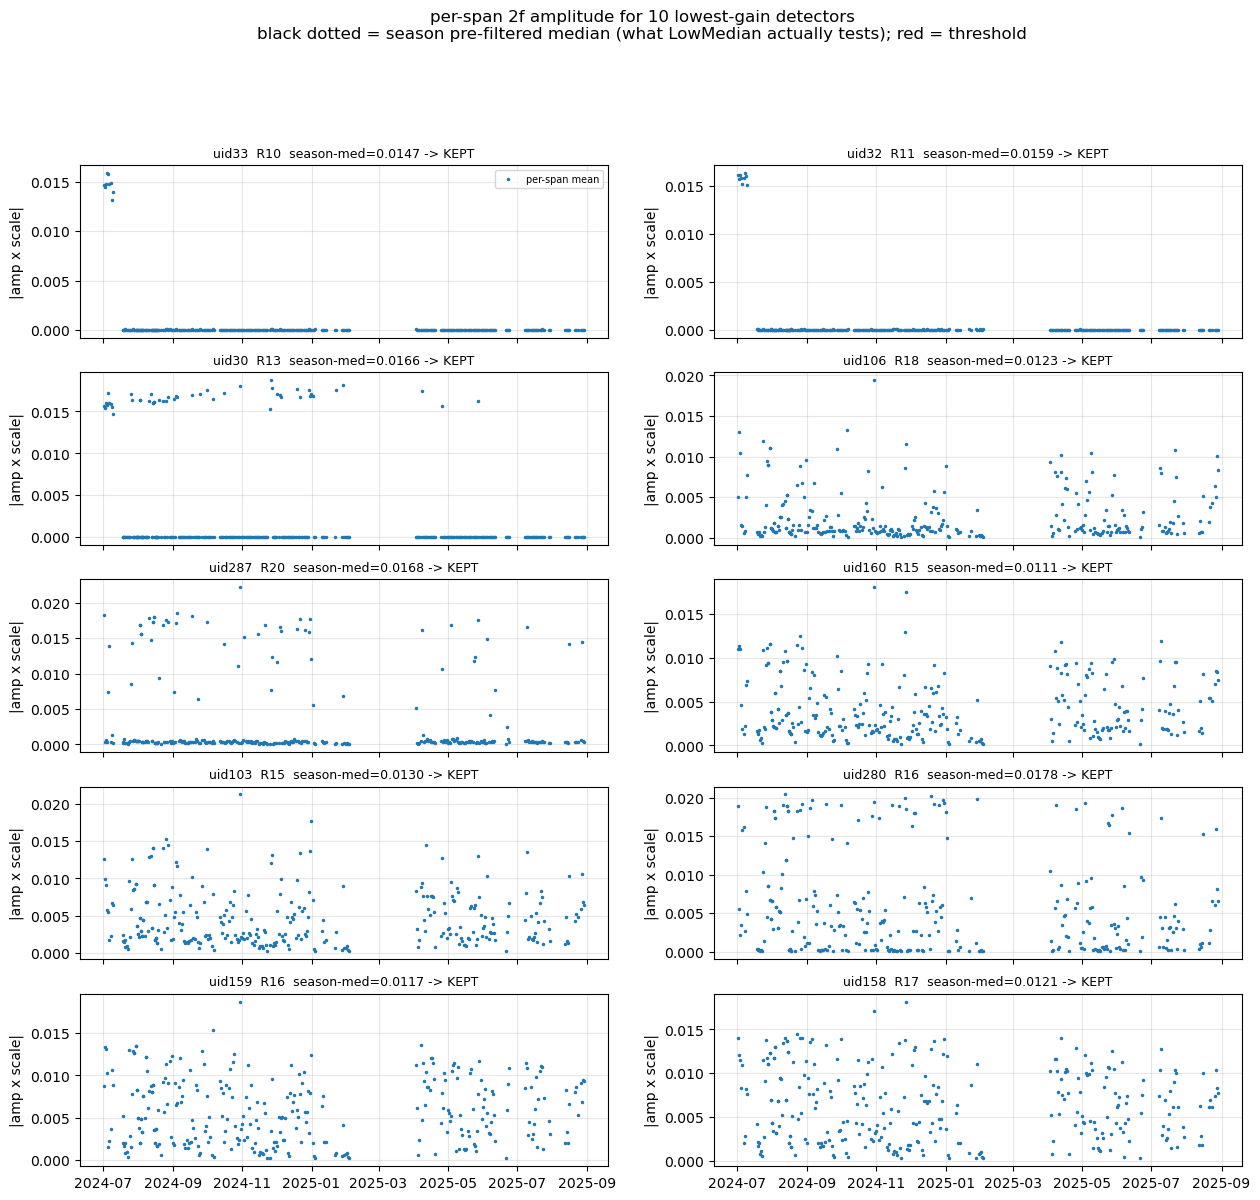

In [4]:
# 10 lowest mean-2f live detectors
low10 = np.where(LIVE & np.isfinite(MEAN2f))[0]
low10 = low10[np.argsort(MEAN2f[low10])][:10]
print('lowest-gain uids:', [(int(u), round(MEAN2f[u], 4), int(ROW[u])) for u in low10])

con = sqlite3.connect(f'file:{DB}?mode=ro', uri=True)
q = f"""SELECT t.det_uid AS uid, s.span_id AS span, s.timestamp AS ts,
               ABS(t.amplitude*t.scaling_factor) AS a, t.quality AS q
        FROM templates t JOIN segments s ON t.segment_id=s.id
        WHERE t.det_uid IN ({','.join(map(str, low10))})"""
df = pd.read_sql_query(q, con); con.close()

ps = (df.groupby(['uid', 'span'])
        .agg(ts=('ts', 'min'), mean=('a', 'mean'), median=('a', 'median'))
        .reset_index())
ps['date'] = pd.to_datetime(ps['ts'], unit='s')

# season-wide PRE-FILTERED median = the actual LowMedian cut metric
filt = df[(df['q'] >= QTHR) & (df['a'] >= MINBASE)]
season_med = filt.groupby('uid')['a'].median()

fig, axes = plt.subplots(5, 2, figsize=(15, 13), sharex=True); axes = axes.flat
for ax, u in zip(axes, low10):
    d = ps[ps.uid == u].sort_values('ts')
    ax.plot(d['date'], d['mean'],   '.', ms=3, color='C0', label='per-span mean')
    sm = season_med.get(u, np.nan)
    verdict = 'CUT' if sm < MINMED else 'KEPT'
    ax.set_title(f'uid{int(u)}  R{int(ROW[u])}  season-med={sm:.4f} -> {verdict}', fontsize=9)
    ax.set_ylabel('|amp x scale|'); ax.grid(alpha=.3)
axes[0].legend(fontsize=7)
fig.suptitle('per-span 2f amplitude for 10 lowest-gain detectors\n'
             'black dotted = season pre-filtered median (what LowMedian actually tests); red = threshold', y=1.0)
plt.show()

In [5]:
# uid in ascending 2f amplitude
order

array([ 33,  32,  30, 106, 287, 160, 103, 280, 159, 158, 154,   7, 405,
       360, 161, 406, 303, 401, 281, 331, 127, 407, 404, 156, 102, 330,
       408, 110, 304, 162, 358, 327, 449, 361, 409, 448,  89, 301, 338,
       374, 128, 370,  44, 447, 282, 289, 415, 163, 372, 442, 113,  90,
       164,   3, 417, 441,  67, 336,  79, 414,  45,  82,  48, 305, 337,
       356,  71, 353,  92, 444, 375, 130, 126, 332, 450, 120,  70, 339,
       140, 168, 135,  81,  84, 169,  86,  75, 133, 418, 145, 340,  85,
        97, 124, 172,   0, 167, 451,  76, 341,  15,   6,   8, 334, 129,
       420,  80, 348,  20,  17, 248,  74, 368, 344,  96, 316,  77, 351,
       302, 363, 148,  26, 412, 132,  49,  91,  10, 323, 369, 419, 362,
       293, 377, 214, 343, 422, 225,  72,  23, 423, 324, 466,  12, 177,
       294, 170, 141, 306, 314,   4,  87,  98,  47, 346, 452, 114, 309,
       468,  29,  68, 321, 212, 116, 463, 235, 434, 121, 516, 173,  94,
       517, 233, 349, 119, 174, 317, 263, 465, 515, 320, 277, 26

- this plot shows that the consistently dead detectors are cut by ModTemplateQualityAmpConditionCut

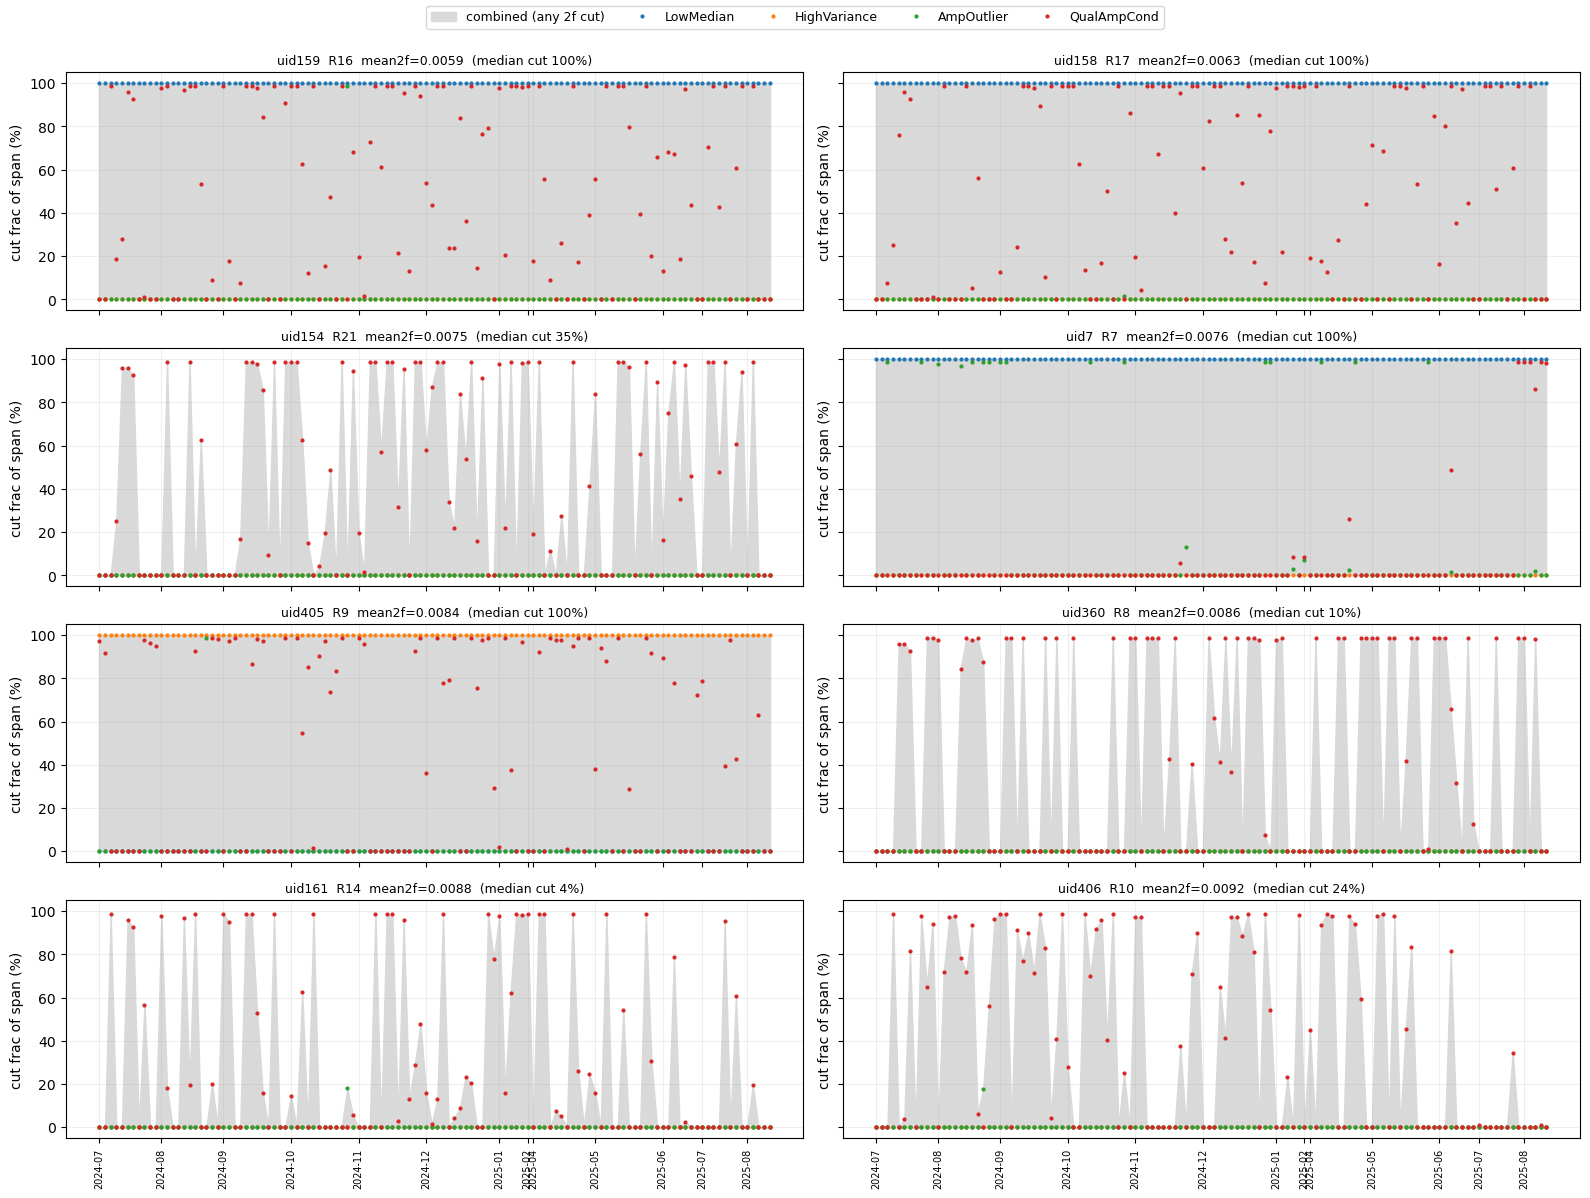

In [6]:
# Cut fraction of the four 2f cuts, per span and detector
UIDS = [33,  32,  30, 106, 287, 160, 103, 280]  # the 8 deadest uids  
UIDS = [159, 158, 154, 7, 405, 360, 161, 406]

spans = sorted(os.path.basename(d) for d in glob.glob(f'{DTOD}/2024-*') + glob.glob(f'{DTOD}/2025-*')
               if os.path.isdir(d) and os.path.exists(f'{d}/cut_dict'))
SUB = [spans[i] for i in np.linspace(0, len(spans) - 1, min(120, len(spans))).astype(int)]

def load_span_masks(sp):
    out = {}
    for f in F2F:
        try: tc = DpipeTODCuts.from_cuts_file(f'{DTOD}/{sp}/cut_dict/{f}.cuts')
        except Exception: continue
        um = {int(x): i for i, x in enumerate(tc.det_uid)} # maps detector UID to row index
        out[f] = (tc, um)
    return out

# CF[span, det, cuttype] cut fraction; COMB[span,det] = OR of the 4 masks
CF   = np.full((len(SUB), len(UIDS), len(F2F)), np.nan)
COMB = np.full((len(SUB), len(UIDS)), np.nan)
for k, sp in enumerate(SUB):
    M = load_span_masks(sp)
    for j, u in enumerate(UIDS):
        union = None
        for fi, f in enumerate(F2F):
            if f not in M: continue
            tc, um = M[f]
            mk = None
            if u in um:
                cv = tc.cuts[um[u]] # gets the cut vector for detector u
                if len(cv) > 0: mk = cv.get_mask()
            CF[k, j, fi] = 0.0 if mk is None else mk.mean() # fraction of sample removed by each cut
            if mk is not None: union = mk.copy() if union is None else (union | mk)
        COMB[k, j] = 0.0 if union is None else union.mean() # fraction of sample removed by any of the 4 cuts

x = np.arange(len(SUB))
tick = [(i, m) for i, m in ((i, s[:7]) for i, s in enumerate(SUB)) if i == 0 or m != SUB[i - 1][:7]]
nc = 2; nr = int(np.ceil(len(UIDS) / nc))
fig, axes = plt.subplots(nr, nc, figsize=(16, 3 * nr), sharex=True, sharey=True); axes = axes.flat
for j, u in enumerate(UIDS):
    ax = axes[j]
    ax.fill_between(x, 0, COMB[:, j] * 100, color='0.85', zorder=0, label='combined (any 2f cut)')
    for fi in range(len(F2F)):
        ax.plot(x, CF[:, j, fi] * 100, '.', ms=4, color=CCOL[fi], label=SHORT[fi] if j == 0 else None)
    ax.set_ylim(-5, 105); ax.grid(alpha=.2); ax.set_ylabel('cut frac of span (%)')
    ax.set_title(f'uid{u}  R{int(ROW[u])}  mean2f={MEAN2f[u]:.4f}  '
                 f'(median cut {np.nanmedian(COMB[:, j])*100:.0f}%)', fontsize=9)
    ax.set_xticks([t[0] for t in tick]); ax.set_xticklabels([t[1] for t in tick], rotation=90, fontsize=7)
for j in range(len(UIDS), len(axes)): axes[j].axis('off')
fig.legend(*axes[0].get_legend_handles_labels(), ncol=5, loc='upper center', fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

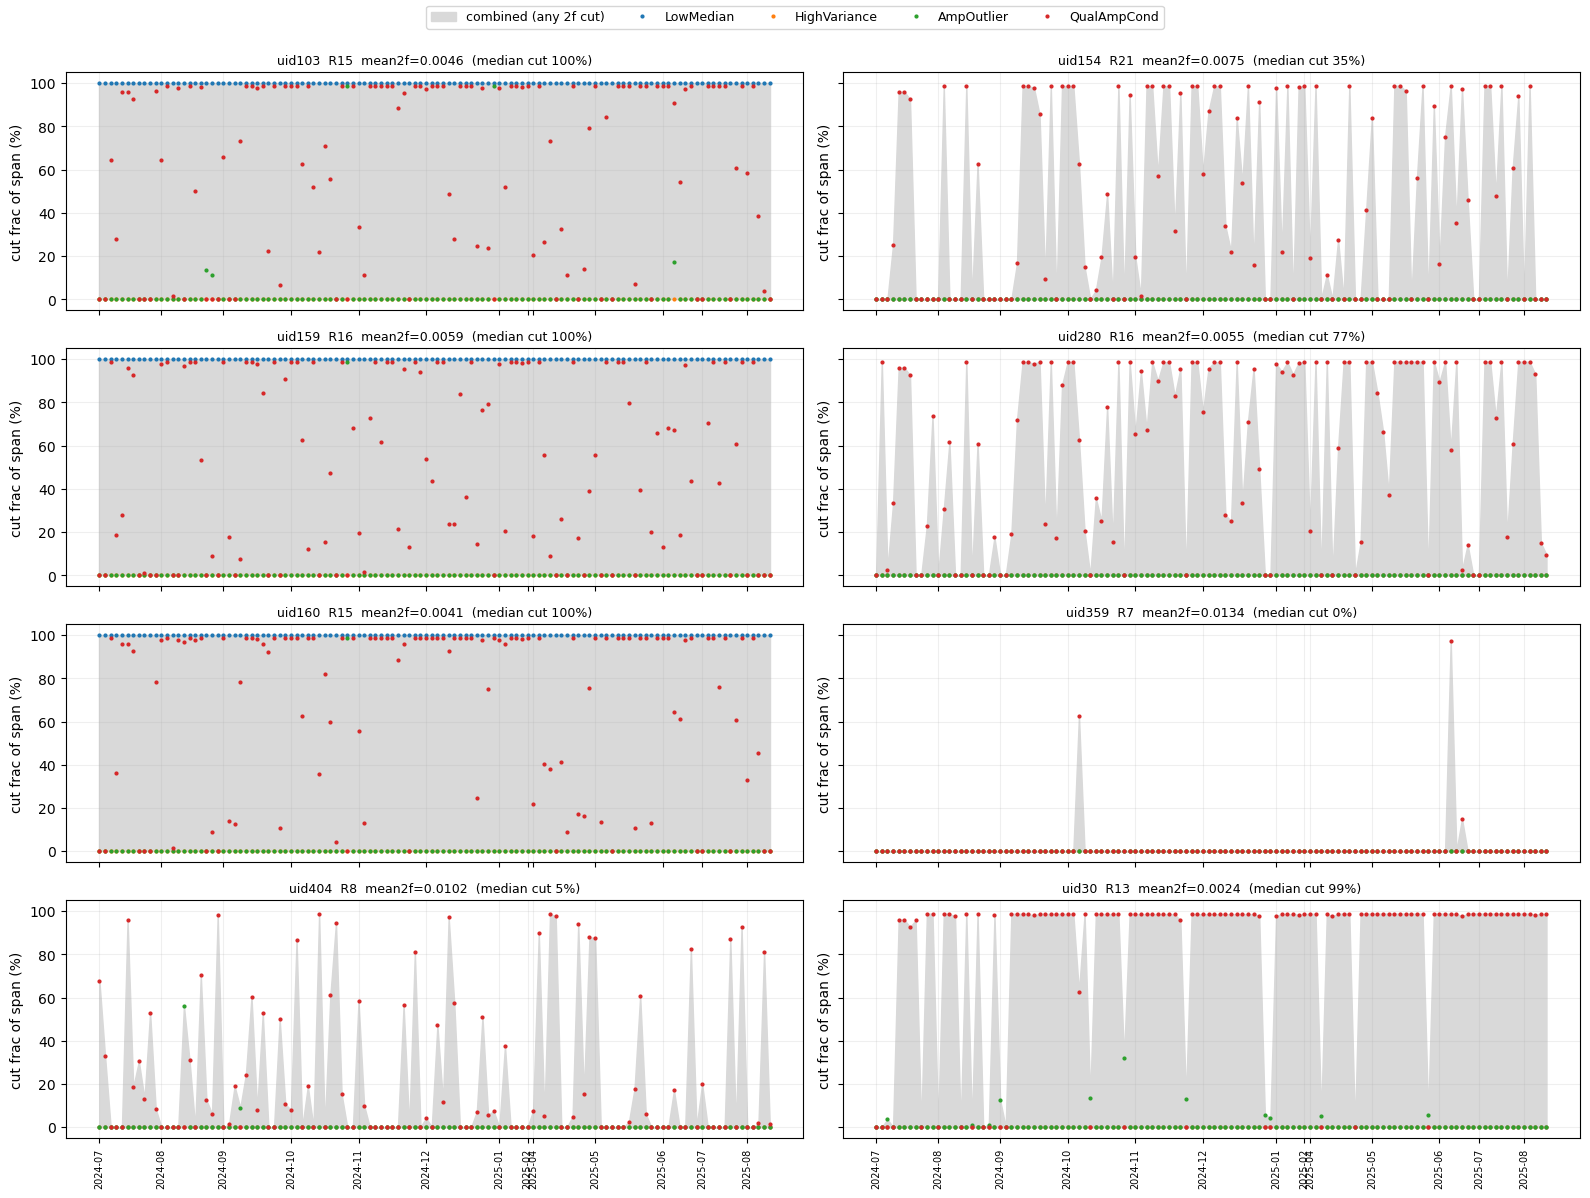

In [22]:
# Cut fraction of the four 2f cuts, per span and detector
#UIDS = [0, 1, 4, 6, 612, 613, 614, 609] # good detectors
# UIDS = [3, 44, 90, 102, 492, 494, 517, 520] # ok detectors
UIDS = [103, 154, 159, 280, 160, 359, 404, 30] # bad detectors

spans = sorted(os.path.basename(d) for d in glob.glob(f'{DTOD}/2024-*') + glob.glob(f'{DTOD}/2025-*')
               if os.path.isdir(d) and os.path.exists(f'{d}/cut_dict'))
SUB = [spans[i] for i in np.linspace(0, len(spans) - 1, min(120, len(spans))).astype(int)]
#SUB = spans[(len(spans)//2-60):(len(spans)//2+60)]  # 120 spans somewhere in the middle

def load_span_masks(sp):
    out = {}
    for f in F2F:
        try: tc = DpipeTODCuts.from_cuts_file(f'{DTOD}/{sp}/cut_dict/{f}.cuts')
        except Exception: continue
        um = {int(x): i for i, x in enumerate(tc.det_uid)} # maps detector UID to row index
        out[f] = (tc, um)
    return out

# CF[span, det, cuttype] cut fraction; COMB[span,det] = OR of the 4 masks
CF   = np.full((len(SUB), len(UIDS), len(F2F)), np.nan)
COMB = np.full((len(SUB), len(UIDS)), np.nan)
for k, sp in enumerate(SUB):
    M = load_span_masks(sp)
    for j, u in enumerate(UIDS):
        union = None
        for fi, f in enumerate(F2F):
            if f not in M: continue
            tc, um = M[f]
            mk = None
            if u in um:
                cv = tc.cuts[um[u]] # gets the cut vector for detector u
                if len(cv) > 0: mk = cv.get_mask()
            CF[k, j, fi] = 0.0 if mk is None else mk.mean() # fraction of sample removed by each cut
            if mk is not None: union = mk.copy() if union is None else (union | mk)
        COMB[k, j] = 0.0 if union is None else union.mean() # fraction of sample removed by any of the 4 cuts

x = np.arange(len(SUB))
tick = [(i, m) for i, m in ((i, s[:7]) for i, s in enumerate(SUB)) if i == 0 or m != SUB[i - 1][:7]]
nc = 2; nr = int(np.ceil(len(UIDS) / nc))
fig, axes = plt.subplots(nr, nc, figsize=(16, 3 * nr), sharex=True, sharey=True); axes = axes.flat
for j, u in enumerate(UIDS):
    ax = axes[j]
    ax.fill_between(x, 0, COMB[:, j] * 100, color='0.85', zorder=0, label='combined (any 2f cut)')
    for fi in range(len(F2F)):
        ax.plot(x, CF[:, j, fi] * 100, '.', ms=4, color=CCOL[fi], label=SHORT[fi] if j == 0 else None)
    ax.set_ylim(-5, 105); ax.grid(alpha=.2); ax.set_ylabel('cut frac of span (%)')
    ax.set_title(f'uid{u}  R{int(ROW[u])}  mean2f={MEAN2f[u]:.4f}  '
                 f'(median cut {np.nanmedian(COMB[:, j])*100:.0f}%)', fontsize=9)
    ax.set_xticks([t[0] for t in tick]); ax.set_xticklabels([t[1] for t in tick], rotation=90, fontsize=7)
for j in range(len(UIDS), len(axes)): axes[j].axis('off')
fig.legend(*axes[0].get_legend_handles_labels(), ncol=5, loc='upper center', fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

## ModTemplateQualityAmpCut

- this plot shows the 2f cut for specific spans
- again it shows that the deadest uids are fully cut
- so the issue is not in the fully dead uids, but uids that has high enough 2f amplitude to survive the cut but still low relative to others

plotting uids: [(159, 0.0059, 16), (158, 0.0063, 17), (154, 0.0075, 21), (7, 0.0076, 7), (405, 0.0084, 9), (360, 0.0086, 8), (161, 0.0088, 14), (406, 0.0092, 10), (303, 0.0095, 4), (401, 0.0096, 5)]


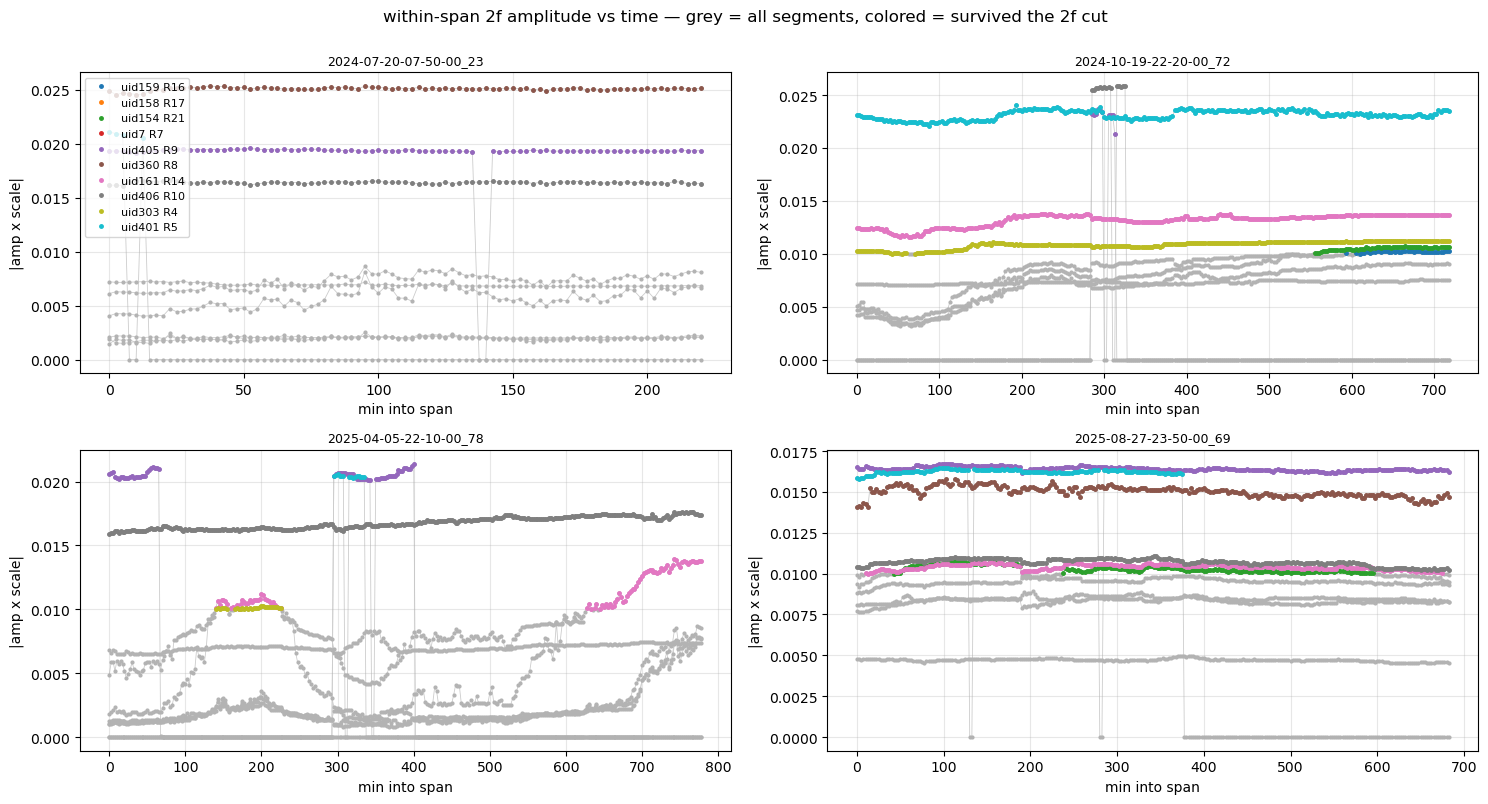

In [3]:
MINMED, MINBASE, QTHR = 0.01045, 0.01, 0.95     # LowMedian thr / pre-filter amp / quality

UIDS = [159, 158, 154,   7, 405,
       360, 161, 406, 303, 401] 
MAXVAR = 4.382e-5
COLS = plt.cm.tab10(np.arange(len(UIDS)) % 10)
print('plotting uids:', [(u, round(MEAN2f[u], 4), int(ROW[u])) for u in UIDS])

con = sqlite3.connect(f'file:{DB}?mode=ro', uri=True)
sid = [r[0] for r in con.execute("SELECT id FROM spans ORDER BY id")]
PICK = [sid[i] for i in np.linspace(0, len(sid) - 1, 4).astype(int)]
allrows = pd.read_sql_query(f"""SELECT t.det_uid uid, s.span_id span, s.timestamp ts,
                                ABS(t.amplitude*t.scaling_factor) a, t.quality q
                                FROM templates t JOIN segments s ON t.segment_id=s.id
                                WHERE t.det_uid IN ({','.join(map(str, UIDS))})""", con)
paths = dict(con.execute(f"SELECT id,path FROM spans WHERE id IN ({','.join(map(str,PICK))})"))
con.close()

# whole-DB cut parameters per detector (pre-filtered, = what the real cut sees)
params = {}
for u in UIDS:
    da = allrows[allrows.uid == u]
    pf = da[(da.q >= QTHR) & (da.a >= MINBASE)]['a']
    if len(pf):
        q1, q3 = pf.quantile([.25, .75]); iqr = q3 - q1
        params[u] = dict(lowmed=pf.median() < MINMED, highvar=pf.var(ddof=0) > MAXVAR,
                         lo=q1 - 1.5 * iqr, hi=q3 + 1.5 * iqr)
    else:
        params[u] = dict(lowmed=True, highvar=False, lo=np.inf, hi=-np.inf)

def survived(u, a, q):                     # True where segment is kept by ALL 4 cuts
    p = params[u]
    cut = p['lowmed'] | p['highvar'] | (a < p['lo']) | (a > p['hi']) | (q < QTHR) | (a < MINBASE)
    return ~cut

fig, axes = plt.subplots(2, 2, figsize=(15, 8)); axes = axes.flat
for ax, sp in zip(axes, PICK):
    g = allrows[allrows.span == sp]
    t0 = g['ts'].min()
    for u, col in zip(UIDS, COLS):
        d = g[g.uid == u].sort_values('ts')
        if not len(d): continue
        x = ((d['ts'] - t0) / 60).to_numpy(); a = d['a'].to_numpy(); q = d['q'].to_numpy()
        keep = survived(u, a, q)
        ax.plot(x, a, '-', lw=.6, color='0.8', zorder=0)            # original (all segments), grey
        ax.plot(x, a, '.', ms=4, color='0.7', zorder=1)
        ax.plot(x[keep], a[keep], '.', ms=5, color=col, zorder=2, label=f'uid{u} R{ROW[u]}')  # survived, colored
    ax.set_title(paths[sp], fontsize=9); ax.set_xlabel('min into span'); ax.grid(alpha=.3)
    ax.set_ylabel('|amp x scale|')
axes[0].legend(fontsize=8, loc='upper left')
fig.suptitle('within-span 2f amplitude vs time — grey = all segments, colored = survived the 2f cut', y=1.0)
plt.tight_layout(); plt.show()

- circling back to the mux_a vs mux_b mismatch, even after the deadest uids are cut, this plot shows that the 2f ampltiude of mux_b is still consistently lower than mux_a

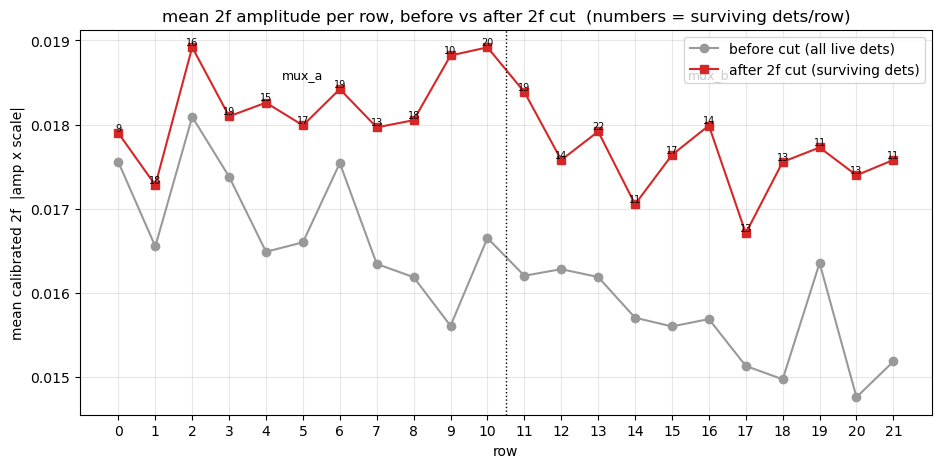

In [3]:
# --- per-row mean 2f, before vs after the 2f cut ---
CUTCACHE = '/tmp/2f_cut_study_postcut.npz'
CUTCACHE = '/none'
MAXVAR = 4.382e-5
if os.path.exists(CUTCACHE):
    z = np.load(CUTCACHE); pmean, pmed, pvar, pn = z['mean'], z['med'], z['var'], z['n']
else:
    con = sqlite3.connect(f'file:{DB}?mode=ro', uri=True)
    pf = pd.read_sql_query(                      # segments surviving QualAmpCond (= the pre-filter)
        "SELECT det_uid AS uid, ABS(amplitude*scaling_factor) AS a "
        "FROM templates WHERE quality>=0.95 AND ABS(amplitude*scaling_factor)>=0.01", con)
    con.close()
    g = pf.groupby('uid')['a']
    pmean = np.full(NDET, np.nan); pmed = np.full(NDET, np.nan)
    pvar = np.full(NDET, np.nan); pn = np.zeros(NDET)
    for u, m in g.mean().items():
        if u < NDET: pmean[u] = m
    for u, m in g.median().items():
        if u < NDET: pmed[u] = m
    for u, m in g.var(ddof=0).items():
        if u < NDET: pvar[u] = m
    for u, m in g.size().items():
        if u < NDET: pn[u] = m
    #np.savez(CUTCACHE, mean=pmean, med=pmed, var=pvar, n=pn)

# whole-detector verdicts on the pre-filtered data
survive = (pmed >= MINMED) & (pvar <= MAXVAR) & (pn > 0)   # passes LowMedian AND HighVariance

rows = np.arange(22)
rowidx = ROW.astype(float)
def per_row(mask, vals):
    out = np.full(len(rows), np.nan); cnt = np.zeros(len(rows))
    for r in rows:
        sel = mask & (rowidx == r) & np.isfinite(vals)
        if sel.any(): out[r] = np.nanmean(vals[sel]); cnt[r] = sel.sum()
    return out, cnt

before, nbef = per_row(LIVE, MEAN2f)                 # all live dets, raw mean (all segments)
after,  naft = per_row(LIVE & survive, pmean)        # surviving dets, mean of surviving segments

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(rows, before, 'o-', color='0.6', label='before cut (all live dets)')
ax.plot(rows, after,  's-', color='C3', label='after 2f cut (surviving dets)')
ax.axvline(10.5, color='k', ls=':', lw=1)
ax.text(5, ax.get_ylim()[1]*0.97, 'mux_a', ha='center', fontsize=9)
ax.text(16, ax.get_ylim()[1]*0.97, 'mux_b', ha='center', fontsize=9)
for r in rows:
    if np.isfinite(after[r]):
        ax.annotate(f'{int(naft[r])}', (r, after[r]), fontsize=7, ha='center', va='bottom')
ax.set_xlabel('row'); ax.set_ylabel('mean calibrated 2f  |amp x scale|')
ax.set_xticks(rows); ax.grid(alpha=.3); ax.legend()
ax.set_title('mean 2f amplitude per row, before vs after 2f cut  (numbers = surviving dets/row)')
plt.show()

# MY TESTING

In [3]:
# load in template table from database
con = sqlite3.connect(f'file:{DB}?mode=ro', uri=True)

pf = pd.read_sql_query(
    "SELECT det_uid AS uid, "
    "segment_id, "
    "ABS(amplitude*scaling_factor) AS a, "
    "quality "
    "FROM templates",
    con
)

con.close()

In [4]:
# load in segment/span table from database
con = sqlite3.connect(f'file:{DB}?mode=ro', uri=True)

df_spans = pd.read_sql_query(
    "SELECT *"
    "FROM segments",
    con
)

con.close()

In [5]:
# load in segment/span table from database
con = sqlite3.connect(f'file:{DB}?mode=ro', uri=True)

spans = pd.read_sql_query(
    "SELECT *"
    "FROM spans",
    con
)

con.close()
spans.sort_values(by='path', ascending=True, inplace=True)
spans

,id,path,processed_time,boresight,elevation
13,27,2024-07-01-21-30-00_71,2026-02-03T15:44:30.233853,45,None
19,35,2024-07-02-21-30-00_86,2026-02-03T15:56:55.811663,30,None
20,36,2024-07-03-21-40-00_85,2026-02-03T15:57:27.797898,45,None
18,34,2024-07-04-21-40-00_85,2026-02-03T15:55:36.990202,-45,None
17,33,2024-07-05-22-10-00_82,2026-02-03T15:54:41.924257,-30,None
...,...,...,...,...,...
285,301,2025-08-23-22-50-00_75,2026-02-05T21:58:37.637661,-15,None
286,302,2025-08-25-22-00-00_80,2026-02-05T22:06:36.854644,15,None
287,303,2025-08-26-23-00-00_74,2026-02-05T22:14:06.715359,30,None
289,305,2025-08-27-23-50-00_69,2026-02-05T22:16:08.360623,45,None


In [6]:
span_info = pd.merge(df_spans, spans, left_on='span_id', right_on="id", how='inner').drop(columns=['id_x', 'id_y','subdivision_index', 'mod_freq', 'modulator_type', 'site_pwv', 'timestamp', 'processed_time', 'boresight', 'elevation'])
span_info = span_info.set_index("span_id")
span_info

,path
span_id,
3,2024-07-20-07-50-00_23
3,2024-07-20-07-50-00_23
3,2024-07-20-07-50-00_23
3,2024-07-20-07-50-00_23
3,2024-07-20-07-50-00_23
...,...
305,2025-08-27-23-50-00_69
305,2025-08-27-23-50-00_69
305,2025-08-27-23-50-00_69


In [7]:
span_info[span_info["path"].str.startswith("2024-12-05")]

,path
span_id,
163,2024-12-05-22-40-00_69
163,2024-12-05-22-40-00_69
163,2024-12-05-22-40-00_69
163,2024-12-05-22-40-00_69
163,2024-12-05-22-40-00_69
...,...
163,2024-12-05-22-40-00_69
163,2024-12-05-22-40-00_69
163,2024-12-05-22-40-00_69


In [12]:
span_info[span_info.index==160]

,path
span_id,
160,2024-12-04-22-40-00_69
160,2024-12-04-22-40-00_69
160,2024-12-04-22-40-00_69
160,2024-12-04-22-40-00_69
160,2024-12-04-22-40-00_69
...,...
160,2024-12-04-22-40-00_69
160,2024-12-04-22-40-00_69
160,2024-12-04-22-40-00_69


In [8]:
# connect data to each span - merging template and segment table
full_pf = pd.merge(pf, df_spans, left_on='segment_id', right_on='id', how='inner').drop(columns=['id', 'subdivision_index', 'mod_freq', 'modulator_type', 'site_pwv'])
full_pf = pd.merge(full_pf, spans, left_on='span_id', right_on='id', how='inner').drop(columns=['processed_time', 'boresight', 'elevation', 'id'])
full_pf

,uid,segment_id,a,quality,span_id,timestamp,path
0,0,277,0.015836,0.999986,3,1.721462e+09,2024-07-20-07-50-00_23
1,1,277,0.020045,0.999993,3,1.721462e+09,2024-07-20-07-50-00_23
2,2,277,0.015831,0.999986,3,1.721462e+09,2024-07-20-07-50-00_23
3,3,277,0.017433,0.999990,3,1.721462e+09,2024-07-20-07-50-00_23
4,4,277,0.016855,0.999987,3,1.721462e+09,2024-07-20-07-50-00_23
...,...,...,...,...,...,...,...
26826697,609,86606,0.020063,0.999999,305,1.756380e+09,2025-08-27-23-50-00_69
26826698,612,86606,0.019014,0.999998,305,1.756380e+09,2025-08-27-23-50-00_69
26826699,613,86606,0.026823,0.999999,305,1.756380e+09,2025-08-27-23-50-00_69
26826700,614,86606,0.023450,0.999999,305,1.756380e+09,2025-08-27-23-50-00_69


In [9]:
full_pf[(full_pf['span_id']==3)&(full_pf['uid']==0)]

,uid,segment_id,a,quality,span_id,timestamp,path
0,0,277,0.015836,0.999986,3,1.721462e+09,2024-07-20-07-50-00_23
342,0,278,0.015708,0.999999,3,1.721462e+09,2024-07-20-07-50-00_23
682,0,279,0.015664,0.999999,3,1.721463e+09,2024-07-20-07-50-00_23
1021,0,280,0.015649,0.999999,3,1.721463e+09,2024-07-20-07-50-00_23
1360,0,281,0.015658,0.999999,3,1.721463e+09,2024-07-20-07-50-00_23
...,...,...,...,...,...,...,...
27875,0,361,0.015605,0.999999,3,1.721475e+09,2024-07-20-07-50-00_23
28203,0,362,0.015611,0.999999,3,1.721475e+09,2024-07-20-07-50-00_23
28532,0,363,0.015647,0.999999,3,1.721475e+09,2024-07-20-07-50-00_23
28861,0,364,0.015667,0.999999,3,1.721475e+09,2024-07-20-07-50-00_23


In [ ]:
#df = pd.merge(pf, spans, )
# full_pf.to_csv("combined_df.csv", index=False)

In [9]:
optimize = False
N = 100
MINMED = 0.005
MAXVAR = 1e-6
NSPAN = full_pf['span_id'].max()

total_datapkg = len(full_pf)
results = []

# get good quality data - we only calculate span median, variance, IQR bounds, etc. from this
good_pf = full_pf[full_pf["quality"] >= 0.5]
#g = full_pf.groupby(['uid', 'span_id'])
g = good_pf.groupby(['uid', 'span_id'])

uids = np.sort(full_pf['uid'].unique())
span_ids = np.sort(full_pf['span_id'].unique())

# get mean, variance, number of datapkg's for each detector, span pair
pmean = np.full(NDET, np.nan); pmed = np.full((NDET, NSPAN+1), np.nan)
pvar = np.full((NDET, NSPAN+1), np.nan); pn = np.zeros((NDET, NSPAN+1))
for (uid, span_id), sub in g:
    vals = sub["a"].values
    pmed[uid, span_id] = np.median(vals)
    pvar[uid, span_id] = np.var(vals)
    pn[uid, span_id]   = len(vals)

# SPAN-WIDE CUTS: ModTemplateLowMedianCut, ModTemplateHighVarianceCut
# only keep nonempty spans with median 2f amp >= MINMED, variance <= MAXVAR
span_survive = (pmed >= MINMED) & (pvar <= MAXVAR) & (pn > 0)
det_keep, span_keep = np.where(span_survive)

surviving_pairs = set(zip(det_keep, span_keep))
surviving_pairs_df = pd.DataFrame(
    surviving_pairs,
    columns=["uid", "span_id"]
)

pf_surviving_spans = full_pf.merge(
    surviving_pairs_df,
    on=["uid", "span_id"],
    how="inner"
)

# define IQR bounds of each detecotr
amp_stats = good_pf.groupby("uid")["a"].agg(
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
)

lower_bound = np.full(NDET, np.nan)
upper_bound = np.full(NDET, np.nan)

for uid, row in amp_stats.iterrows():
    if uid < NDET:
        q1 = row["q1"]
        q3 = row["q3"]
        iqr = q3 - q1

        lower_bound[uid] = q1 - 1.5 * iqr
        upper_bound[uid] = q3 + 1.5 * iqr

# defining mux a and mux b masks
mux_a_mask = (ROW.astype(float) <= 10)
mux_b_mask = ~mux_a_mask

print("done with database prep")

# function for optimizing MINBASE so that mux_loss is minimized and surviving data is maximized
def evaluate(minbase, qthr):
    pf_test = pf_surviving_spans[
        (pf_surviving_spans["quality"] >= qthr) &
        (pf_surviving_spans["a"] >= minbase) & 
        (pf_surviving_spans["a"] >= lower_bound[pf_surviving_spans["uid"]]) &
        (pf_surviving_spans["a"] <= upper_bound[pf_surviving_spans["uid"]])
    ]

    if pf_test.empty:
        return np.inf, np.inf

    # Recompute detector means after span cuts
    g = pf_test.groupby("uid")["a"]
    mean_after = g.mean()

    # Fill detector array
    pmean_after = np.full(NDET, np.nan)

    for u, m in mean_after.items():
        if u < NDET: pmean_after[u] = m

    survive = np.isfinite(pmean_after)
    a_data = survive & mux_a_mask
    b_data = survive & mux_b_mask

    if a_data.sum() == 0 or b_data.sum() == 0:
        return np.inf, np.inf
    a = np.nanmean(pmean_after[a_data])
    b = np.nanmean(pmean_after[b_data])

    mux_loss = abs(a - b)
    # strength = (
    #     # (1 - minmed) +
    #     # (maxvar / 1e-4) +
    #     (0.02 - minbase) / 0.02 +
    #     (1 - qthr)
    # )
    surviving_datapkg = len(pf_test)

    return mux_loss, surviving_datapkg

# find the optimal MINBASE, QTHR value
if optimize:
    for i in range(N):

        minbase = np.random.uniform(0.005, 0.014)
        qthr    = np.random.uniform(0.90, 0.99)

        loss, strength = evaluate(minbase, qthr)

        results.append((loss, strength, minbase, qthr))

    best_loss = min(r[0] for r in results)
    eps = 0.5 * best_loss

    candidates = [r for r in results if r[0] <= best_loss + eps]

    best = max(candidates, key=lambda r: r[1])

    print("Best solution:")
    print("mux_loss, strength:", best[0], best[1])
    print("minbase, qthr:", best[2:])


done with database prep


In [36]:
#print(np.count_nonzero(pmed[615]<1e-6))
print(np.nanmean(pmed[615]))

0.02413486577402876


In [ ]:
# DATAPKG CUTS: ModTemplateQualityAmpConditionCut and ModTemplateAmplitudeOutlierCut
# keep datapackages within IQR bounds of the detector, and have good quality fits above qthr, and sufficient amplitude above minbase
def evaluate_cuts(minbase, qthr):
    pf_test = pf_surviving_spans[
        (pf_surviving_spans["quality"] >= qthr) &
        (pf_surviving_spans["a"] >= minbase) & 
        (pf_surviving_spans["a"] >= lower_bound[pf_surviving_spans["uid"]]) &
        (pf_surviving_spans["a"] <= upper_bound[pf_surviving_spans["uid"]])
    ]

    surviving_datapkg = len(pf_test)

    # Recompute detector means after span cuts
    g = pf_test.groupby("uid")["a"]
    mean_after = g.mean()

    # Fill detector array
    pmean_after = np.full(NDET, np.nan)

    for u, m in mean_after.items():
        if u < NDET: pmean_after[u] = m

    survive = np.isfinite(pmean_after)
    a_data = survive & mux_a_mask
    b_data = survive & mux_b_mask

    if a_data.sum() == 0 or b_data.sum() == 0:
        return np.inf, np.inf
    a = np.nanmean(pmean_after[a_data])
    b = np.nanmean(pmean_after[b_data])

    mux_loss = abs(a - b)
    return mux_loss, surviving_datapkg/total_datapkg

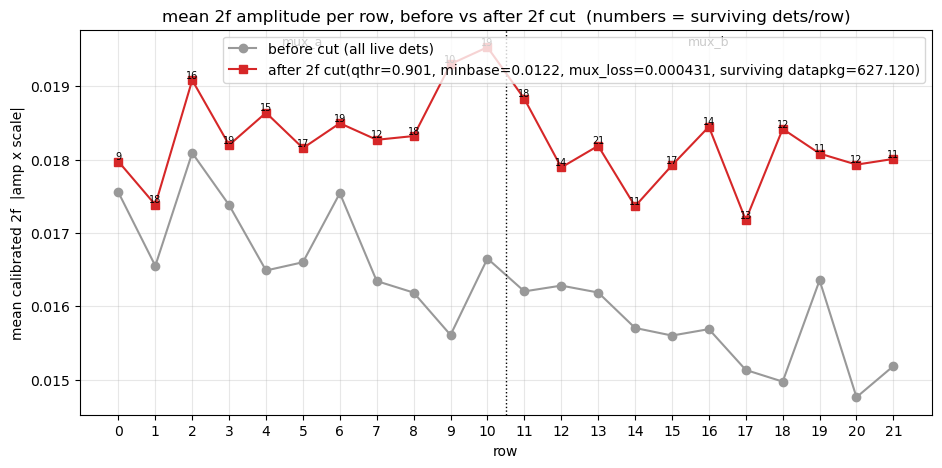

In [ ]:
rows = np.arange(22)
rowidx = ROW.astype(float)
## --------------------PER_ROW NEEDS TO BE FIXED TO ACCOMODATE THE SPANS-------------------------
def per_row(mask, vals):
    out = np.full(len(rows), np.nan); cnt = np.zeros(len(rows))
    for r in rows:
        sel = mask & (rowidx == r) & np.isfinite(vals)
        if sel.any(): out[r] = np.nanmean(vals[sel]); cnt[r] = sel.sum()
    return out, cnt

total_datapkg = len(pf)

pf_best = pf_surviving_spans[
    (pf_surviving_spans["quality"] >= 0.95) &
    (pf_surviving_spans["a"] >= 0.0122) & 
    (pf_surviving_spans["a"] >= lower_bound[pf_surviving_spans["uid"]]) &
    (pf_surviving_spans["a"] <= upper_bound[pf_surviving_spans["uid"]])
]

surviving_datapkg = len(pf_best)

# Recompute detector means after span cuts
g = pf_best.groupby("uid")["a"]
mean_after = g.mean()

# Fill detector array
pmean_after = np.full(NDET, np.nan)

for u, m in mean_after.items():
    if u < NDET: pmean_after[u] = m

survive = np.isfinite(pmean_after)

a_data = survive & mux_a_mask
b_data = survive & mux_b_mask

a = np.nanmean(pmean_after[a_data])
b = np.nanmean(pmean_after[b_data])

mux_loss = abs(a - b)

before, nbef = per_row(LIVE, MEAN2f)                 # all live dets, raw mean (all segments)
after,  naft = per_row(LIVE & survive, pmean_after)        # surviving dets, mean of surviving segments

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(rows, before, 'o-', color='0.6', label='before cut (all live dets)')
#ax.plot(rows, after,  's-', color='C3', label=f"after 2f cut(qthr={best[3]:.3f}, minbase={best[2]:.4f}, mux_loss={best[0]:.4f}, surviving datapkg={surviving_datapkg/total_datapkg:.3f})")
ax.plot(rows, after,  's-', color='C3', label=f"after 2f cut(qthr=0.901, minbase=0.0122, mux_loss={mux_loss:.6f}, surviving datapkg={surviving_datapkg/total_datapkg:.3f})")
ax.axvline(10.5, color='k', ls=':', lw=1)
ax.text(5, ax.get_ylim()[1]*0.99, 'mux_a', ha='center', fontsize=9)
ax.text(16, ax.get_ylim()[1]*0.99, 'mux_b', ha='center', fontsize=9)
for r in rows:
    if np.isfinite(after[r]):
        ax.annotate(f'{int(naft[r])}', (r, after[r]), fontsize=7, ha='center', va='bottom')
ax.set_xlabel('row'); ax.set_ylabel('mean calibrated 2f  |amp x scale|')
ax.set_xticks(rows); ax.grid(alpha=.3); ax.legend()
ax.set_title('mean 2f amplitude per row, before vs after 2f cut  (numbers = surviving dets/row)')
plt.show()

### Adjusting MINBASE

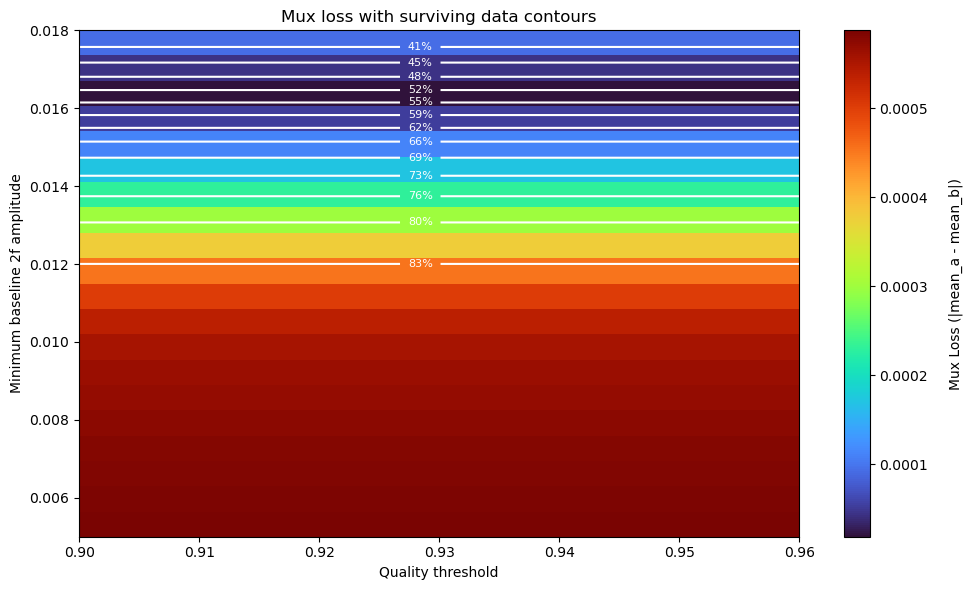

In [ ]:
# ---------------------MINBASE RANGE------------------------
qthr_vals = np.linspace(0.90, 0.96, 20)
minbase_vals = np.linspace(0.005, 0.018, 20)

mux_loss_grid = np.zeros((len(minbase_vals), len(qthr_vals)))
surviving_datapkg_grid = np.zeros((len(minbase_vals), len(qthr_vals)))

for i, minbase in enumerate(minbase_vals):
    for j, qthr in enumerate(qthr_vals):
        mux_loss, surviving_datapkg = evaluate_cuts(minbase, qthr)
        mux_loss_grid[i, j] = mux_loss
        surviving_datapkg_grid[i, j] = surviving_datapkg

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(
    mux_loss_grid, 
    origin='lower', 
    extent=[
        qthr_vals[0], 
        qthr_vals[-1], 
        minbase_vals[0], 
        minbase_vals[-1]
    ], 
    aspect='auto', 
    cmap='turbo'
)

cbar = plt.colorbar(im)
cbar.set_label('Mux Loss (|mean_a - mean_b|)', rotation=90, labelpad=15)

levels = np.linspace(np.nanmin(surviving_datapkg_grid), np.nanmax(surviving_datapkg_grid), 15)
contour = ax.contour(
    qthr_vals, 
    minbase_vals, 
    surviving_datapkg_grid, 
    levels=levels, 
    colors='white', 
    linewidths=1.5
)

ax.clabel(contour, inline=True, fontsize=8, fmt=lambda x: f"{100*x:.0f}%")

ax.set_xlabel("Quality threshold")
ax.set_ylabel("Minimum baseline 2f amplitude")
ax.set_title("Mux loss with surviving data contours")

plt.tight_layout()
plt.show()

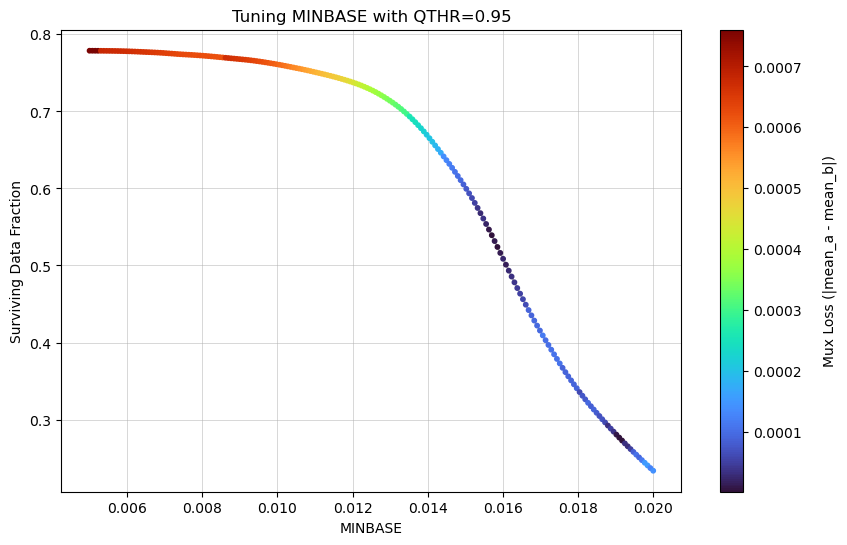

In [16]:
minbase_vals = np.linspace(0.005, 0.02, 200)
mux_loss_list = np.zeros(len(minbase_vals))
surviving_datapkg_list = np.zeros(len(minbase_vals))

for i, minbase in enumerate(minbase_vals):
    mux_loss, surviving_datapkg = evaluate_cuts(minbase, 0.95)
    mux_loss_list[i] = mux_loss
    surviving_datapkg_list[i] = surviving_datapkg

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(minbase_vals, surviving_datapkg_list, color="0.7", zorder=1)

sc = plt.scatter(
    minbase_vals,
    surviving_datapkg_list,
    c=mux_loss_list,
    cmap="turbo",
    s=10, 
    zorder=2
)

cbar = plt.colorbar(sc)
cbar.set_label('Mux Loss (|mean_a - mean_b|)', rotation=90, labelpad=15)
plt.xlabel("MINBASE")
plt.ylabel("Surviving Data Fraction")
plt.title("Tuning MINBASE with QTHR=0.95")
plt.grid(which='major', linewidth=0.5, alpha=0.7)
plt.grid(which='minor', linewidth=0.2, alpha=0.3)
plt.show()

### Sorting Detectors

In [16]:
# evaluate data package cuts ModTemplateQualityAmpConditionCut and ModTemplateAmplitudeOutlierCut
pf_sort = pf_surviving_spans[
    (pf_surviving_spans["quality"] >= 0.95) &
    (pf_surviving_spans["a"] >= 0.0125) &
    (pf_surviving_spans["a"] >= lower_bound[pf_surviving_spans["uid"]]) &
    (pf_surviving_spans["a"] <= upper_bound[pf_surviving_spans["uid"]])
]

# count number of surviving spans per each detector
g = pf_sort.groupby(["uid", "span_id"])

pair_counts = (
    pf_sort.groupby("uid")["span_id"].nunique()
)

# add detectors to the list that had ALL spans cut
all_detectors = set(full_pf["uid"].unique())
surviving_detectors = set(pf_sort["uid"].unique())

cut_detectors = np.array(list(all_detectors - surviving_detectors))

for uid in cut_detectors:
    if uid not in pair_counts.index:
        pair_counts.loc[uid] = 0

print(pair_counts.sort_index(ascending=True))

uid
0      269
1      271
2      238
3      255
4      263
      ... 
609    232
612    241
613    249
614    251
615    252
Name: span_id, Length: 345, dtype: int64


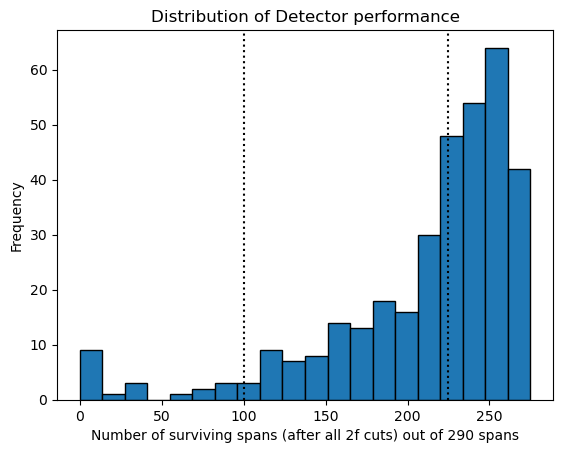

In [17]:
plt.hist(pair_counts, bins=20, edgecolor='black')
plt.xlabel("Number of surviving spans (after all 2f cuts) out of 290 spans")
plt.ylabel("Frequency")
plt.title("Distribution of Detector performance")
plt.axvline(100, color='black', ls=':')
plt.axvline(225, color='black', ls=':')

In [24]:
# group detectors
bad_detectors = pair_counts[pair_counts <= 100]
good_detectors = pair_counts[pair_counts >= 225]
ok_detectors = pair_counts[(pair_counts > 100) & (pair_counts < 225)]

#np.savez("detector_sort.npz", bad_detectors=bad_detectors.index, good_detectors=good_detectors.index, ok_detectors=ok_detectors.index, pair_counts=pair_counts.sort_index(ascending=True))
print(bad_detectors)

uid
102    97
103    11
127    95
154    55
158    28
159    15
160     3
161    73
280    29
281    90
303    12
331    72
359    39
443    89
32      0
33      0
7       0
106     0
30      0
287     0
Name: span_id, dtype: int64


In [48]:
print(good_detectors)

uid
0      269
1      271
2      238
3      255
4      263
      ... 
609    232
612    241
613    249
614    251
615    252
Name: span_id, Length: 189, dtype: int64


In [ ]:
for uid, group in full_pf.groupby("uid"):
    group = group.sort_values("timestamp")

    y = [pmed[uid][span_id] for span_id in group["span_id"]]
    x = group["timestamp"]

    plt.plot(x, y, label=f"uid {uid}")

In [89]:
full_pf

,uid,segment_id,a,quality,span_id,timestamp,path
0,0,277,0.015836,0.999986,3,1.721462e+09,2024-07-20-07-50-00_23
1,1,277,0.020045,0.999993,3,1.721462e+09,2024-07-20-07-50-00_23
2,2,277,0.015831,0.999986,3,1.721462e+09,2024-07-20-07-50-00_23
3,3,277,0.017433,0.999990,3,1.721462e+09,2024-07-20-07-50-00_23
4,4,277,0.016855,0.999987,3,1.721462e+09,2024-07-20-07-50-00_23
...,...,...,...,...,...,...,...
26826697,609,86606,0.020063,0.999999,305,1.756380e+09,2025-08-27-23-50-00_69
26826698,612,86606,0.019014,0.999998,305,1.756380e+09,2025-08-27-23-50-00_69
26826699,613,86606,0.026823,0.999999,305,1.756380e+09,2025-08-27-23-50-00_69
26826700,614,86606,0.023450,0.999999,305,1.756380e+09,2025-08-27-23-50-00_69


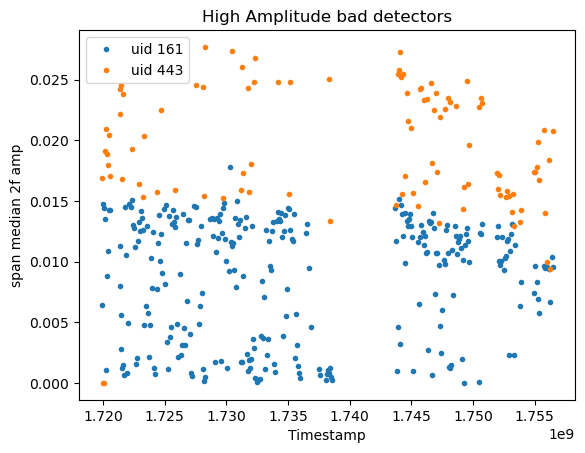

In [11]:
span_times = full_pf.groupby("span_id")["timestamp"].mean()
uid = 161

# plt.plot(
#     span_times.sort_index(),
#     [pmed[uid][span_id] for span_id in span_times.sort_index().keys()], '.', color='b'
# )
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
uid = 443
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
plt.xlabel("Timestamp")
plt.ylabel("span median 2f amp")
plt.legend()
plt.title("High Amplitude bad detectors")
plt.title
plt.show()

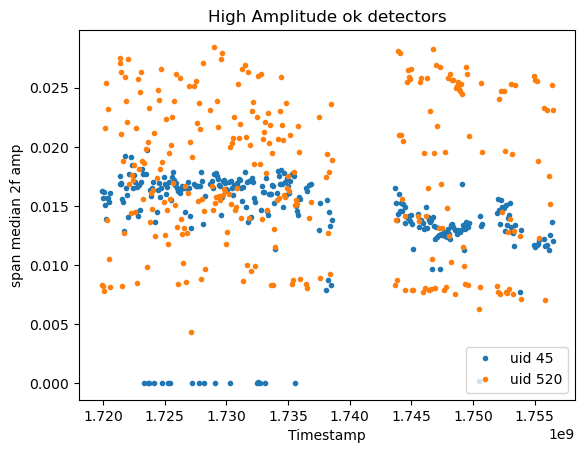

In [14]:
uid = 45
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
uid = 520
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
plt.xlabel("Timestamp")
plt.ylabel("span median 2f amp")
plt.legend()
plt.title("High Amplitude ok detectors")
plt.title
plt.show()

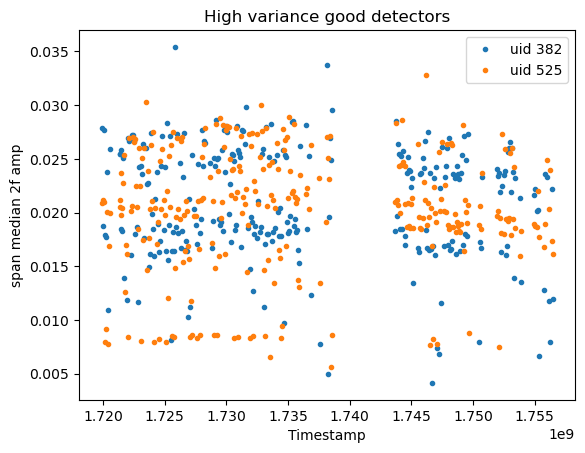

In [28]:
uid = 382
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
uid = 525
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
plt.xlabel("Timestamp")
plt.ylabel("span median 2f amp")
plt.legend()
plt.title("High variance good detectors")
plt.title
plt.show()

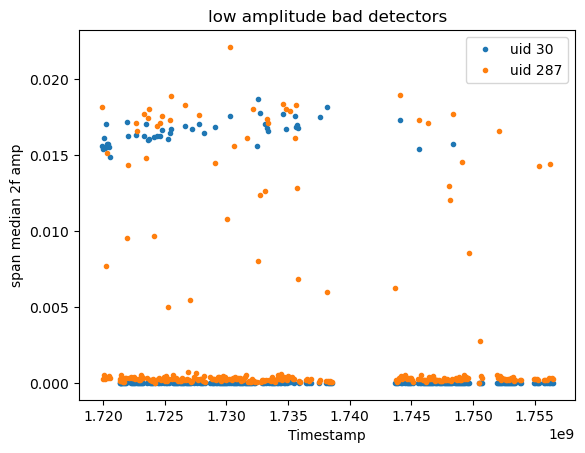

In [29]:
uid = 30
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
uid = 287
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
plt.xlabel("Timestamp")
plt.ylabel("span median 2f amp")
plt.legend()
plt.title("low amplitude bad detectors")
plt.title
plt.show()

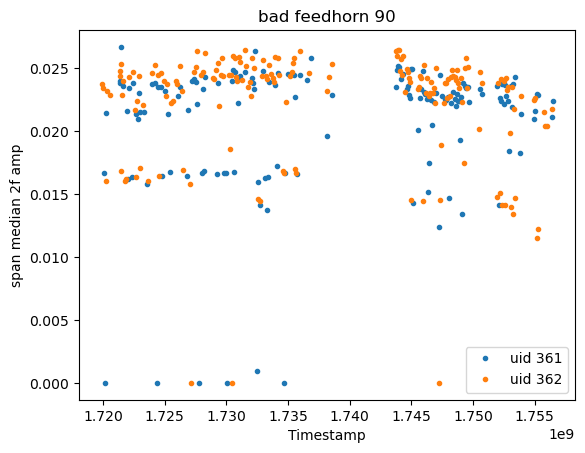

In [15]:
uid = 361
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
uid = 362
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
plt.xlabel("Timestamp")
plt.ylabel("span median 2f amp")
plt.legend()
plt.title("bad feedhorn 90")
plt.title
plt.show()

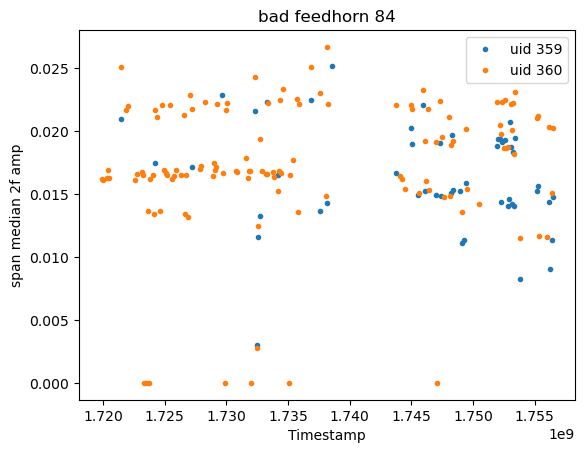

In [22]:
uid = 359
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
uid = 360
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
plt.xlabel("Timestamp")
plt.ylabel("span median 2f amp")
plt.legend()
plt.title("bad feedhorn 84")
plt.title
plt.show()

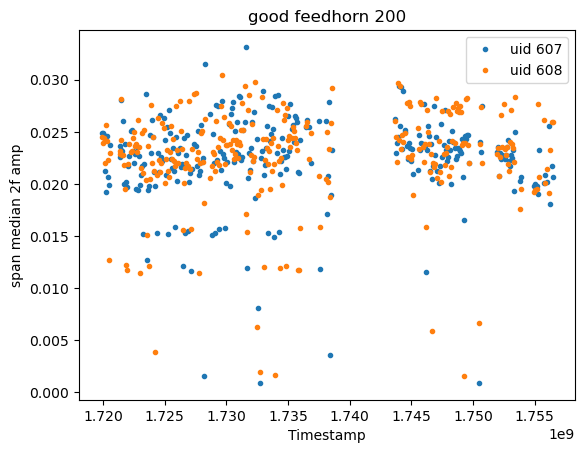

In [31]:
uid = 607
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
uid = 608
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
plt.xlabel("Timestamp")
plt.ylabel("span median 2f amp")
plt.legend()
plt.title("good feedhorn 200")
plt.title
plt.show()

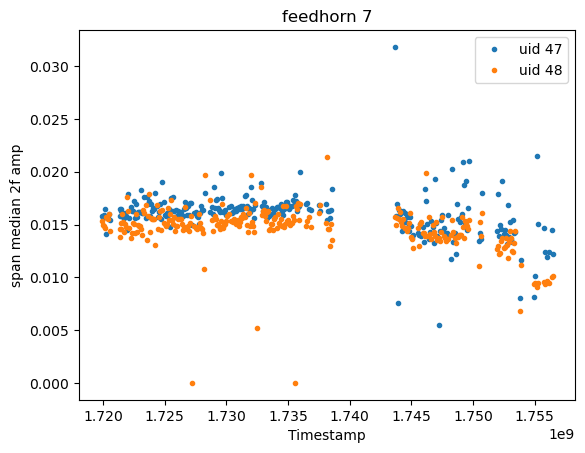

In [36]:
uid = 47
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
uid = 48
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
plt.xlabel("Timestamp")
plt.ylabel("span median 2f amp")
plt.legend()
plt.title("feedhorn 7")
plt.title
plt.show()

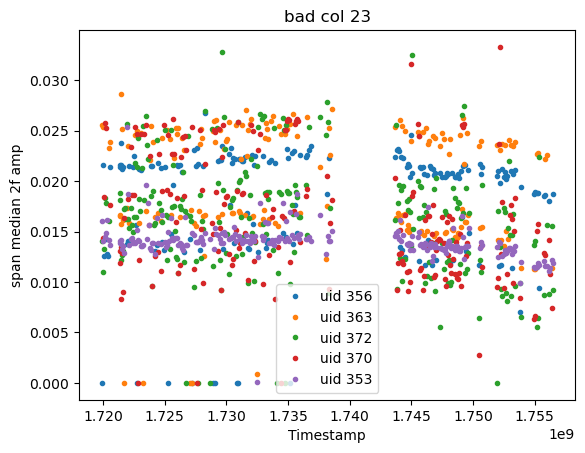

In [35]:
uid = 356
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)

uid = 363
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
uid=372
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
uid = 370
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
uid=353
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
plt.xlabel("Timestamp")
plt.ylabel("span median 2f amp")
plt.legend()
plt.title("bad col 23")
plt.title
plt.show()

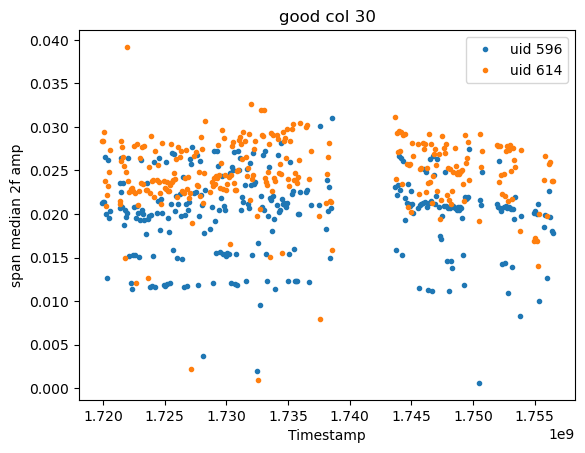

In [32]:
uid = 596
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
# uid = 608
# plt.plot(
#     span_times.sort_values(),
#     [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
# )
uid = 614
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
plt.xlabel("Timestamp")
plt.ylabel("span median 2f amp")
plt.legend()
plt.title("good col 30")
plt.title
plt.show()

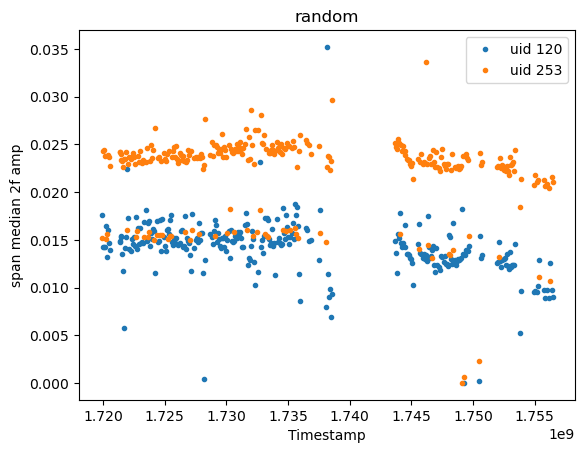

In [27]:
uid = 120
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
uid = 253
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
plt.xlabel("Timestamp")
plt.ylabel("span median 2f amp")
plt.legend()
plt.title("random")
plt.title
plt.show()

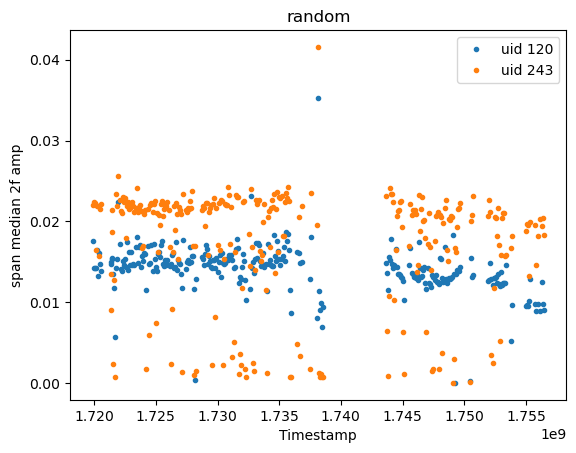

In [29]:
uid = 120
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
uid = 243
plt.plot(
    span_times.sort_values(),
    [pmed[uid][span_id] for span_id in span_times.sort_values().index], '.', label=f"uid {uid}"
)
plt.xlabel("Timestamp")
plt.ylabel("span median 2f amp")
plt.legend()
plt.title("random")
plt.title
plt.show()

In [98]:
full_pf[(full_pf['timestamp'] < 1.725e9) & (full_pf['timestamp'] > 1.722e9)]['span_id'].unique()

array([16, 32, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 67, 68, 69])

In [102]:
print(spans[(spans['id']>=37)&(spans['id']<=69)]['path'].min())
print(spans[(spans['id']>=37)&(spans['id']<=69)]['path'].max())

2024-07-27-21-50-00_83
2024-08-31-01-40-00_57


In [44]:
full_pf[(full_pf['uid']==47)&(full_pf['timestamp'] > 1.745e9)&(full_pf['a'] < 0.005)]['span_id'].unique()


array([221, 233, 241, 262, 270, 278, 279, 282, 285, 294, 295, 298])

In [49]:
print(span_times[241])
print(pmed[47][241])
full_pf[(full_pf['uid']==47)&(full_pf['span_id']==241)]

1747197283.730002
0.0054573267449703824


,uid,segment_id,a,quality,span_id,timestamp,path
19853593,47,65508,0.003479,0.952288,241,1.747192e+09,2025-05-13-21-40-00_83
19853929,47,65509,0.005137,0.981230,241,1.747192e+09,2025-05-13-21-40-00_83
19854266,47,65510,0.004569,0.977902,241,1.747192e+09,2025-05-13-21-40-00_83
19854598,47,65511,0.004393,0.986531,241,1.747192e+09,2025-05-13-21-40-00_83
19854929,47,65512,0.003064,0.976649,241,1.747192e+09,2025-05-13-21-40-00_83
19855264,47,65513,0.002775,0.947539,241,1.747193e+09,2025-05-13-21-40-00_83
19855599,47,65514,0.001830,0.858756,241,1.747193e+09,2025-05-13-21-40-00_83
19855930,47,65515,0.001354,0.789967,241,1.747193e+09,2025-05-13-21-40-00_83
19856260,47,65516,0.000429,0.494970,241,1.747193e+09,2025-05-13-21-40-00_83
19856590,47,65517,0.000680,0.611377,241,1.747193e+09,2025-05-13-21-40-00_83


In [59]:
full_pf[
    (full_pf['timestamp'] > 1.747193e9) &
    (full_pf['uid'] == 47)
].sort_values(by='timestamp', ascending=True).head(50)

,uid,segment_id,a,quality,span_id,timestamp,path
19856260,47,65516,0.000429,0.494970,241,1.747193e+09,2025-05-13-21-40-00_83
19856590,47,65517,0.000680,0.611377,241,1.747193e+09,2025-05-13-21-40-00_83
19857577,47,65520,0.005778,0.996931,241,1.747194e+09,2025-05-13-21-40-00_83
19857907,47,65521,0.006920,0.997521,241,1.747194e+09,2025-05-13-21-40-00_83
19858236,47,65522,0.006412,0.998006,241,1.747194e+09,2025-05-13-21-40-00_83
19858563,47,65523,0.007930,0.998169,241,1.747194e+09,2025-05-13-21-40-00_83
19858890,47,65524,0.008805,0.999176,241,1.747194e+09,2025-05-13-21-40-00_83
19859217,47,65525,0.009642,0.999518,241,1.747194e+09,2025-05-13-21-40-00_83
19859544,47,65526,0.010556,0.999702,241,1.747195e+09,2025-05-13-21-40-00_83
19859872,47,65527,0.009793,0.999362,241,1.747195e+09,2025-05-13-21-40-00_83


# things to try
- look at row 17 vs row 21 (why is row 17 not improving much even after massively changing MINBASE?) or row 14 vs row 20
- why were detector 30, 32, 33, 287 kept? 
    - high enough season median
- look for correlation with rows with large variance in the detector 2f amp
- look at parole (per row) plot?? in carol's directory
- tune the parameters until mux a and mux b are equal